In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# https://www.kaggle.com/competitions/titanic/data
titanic_data = pd.read_csv("PUT PATH HERE")
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df = titanic_data.drop(columns=["Cabin"])

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

## Histogram: What is the age distribution of the passengers?

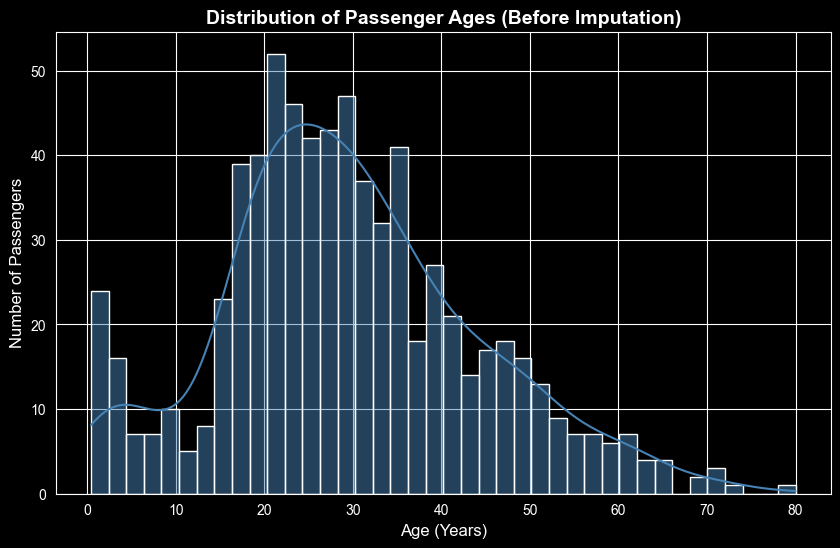

In [9]:
# 1. Set up the matplotlib figure size
plt.figure(figsize=(10, 6))

# 2. Plot the distribution using seaborn
# https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn-histplot
# Notice the .dropna() - we exclude missing values just for this visual
sns.histplot(df['Age'].dropna(), bins=40, kde=True, color='steelblue')

# 3. Add clear labels and a title
plt.title('Distribution of Passenger Ages (Before Imputation)', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# 4. Display the plot
plt.show()

https://medium.com/@post.gourang/understanding-skewness-and-kurtosis-how-they-impact-model-training-04696810dd91

**The Skew:** The data is right-skewed (a long tail towards the older ages).

**The Peak:** The bulk of the passengers are in their 20s and early 30s.

**The Infants:** There is a noticeable secondary spike on the far left for toddlers and infants (ages 0-4).

In [10]:
print(df['Age'].median())
print(df['Age'].mean())

28.0
29.69911764705882


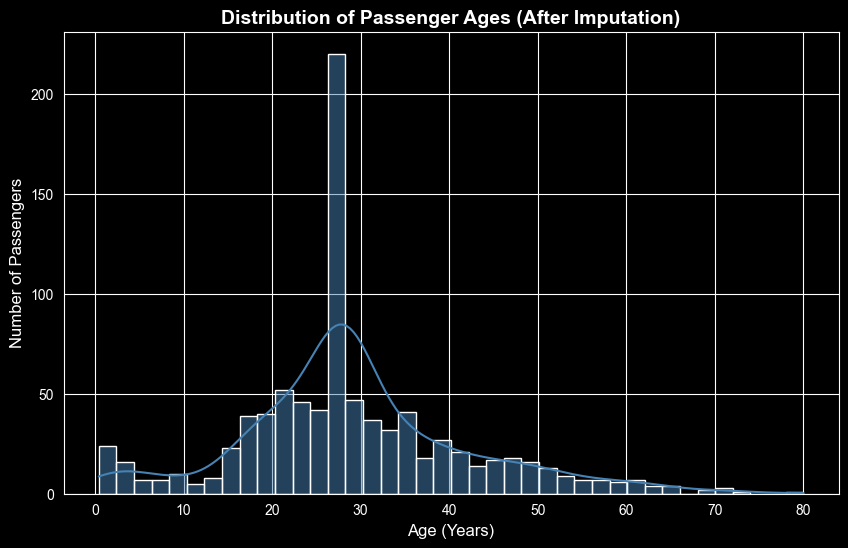

In [11]:
# 1. Create a copy of the dataframe so we don't mess up our original data
df_wrong = df.copy()

# 2. Overwrite the 'Age' column inside that new DataFrame
df_wrong['Age'] = df_wrong['Age'].fillna(df_wrong['Age'].median())

plt.figure(figsize=(10, 6))

# 3. Now this works perfectly, because df_wrong is a DataFrame with an 'Age' column!
sns.histplot(df_wrong['Age'], bins=40, kde=True, color='steelblue')

plt.title('Distribution of Passenger Ages (After Imputation)', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

plt.show()

## **Randomized Imputation based on Standard Deviation**

Most passengers fall within one standard deviation of the average age.
By generating random numbers within this specific range, we maintain the dataset's natural variance.

In [13]:
# 1. Find the mean, standard deviation, and how many missing values we have
age_mean = df['Age'].mean()
age_std = df['Age'].std()

print(f"""Mean Age: {age_mean}
Standard Deviation: {age_std}
""")

Mean Age: 29.69911764705882
Standard Deviation: 14.526497332334042



In [14]:
import numpy as np
null_count = df['Age'].isnull().sum()

# 2. Generate an array of random ages within one standard deviation of the mean
# np.random.randint(low, high, size)
random_ages = np.random.randint(age_mean - age_std, age_mean + age_std, size=null_count)

# 3. Locate the missing values in pandas and fill them with our random array
df.loc[df['Age'].isnull(), 'Age'] = random_ages

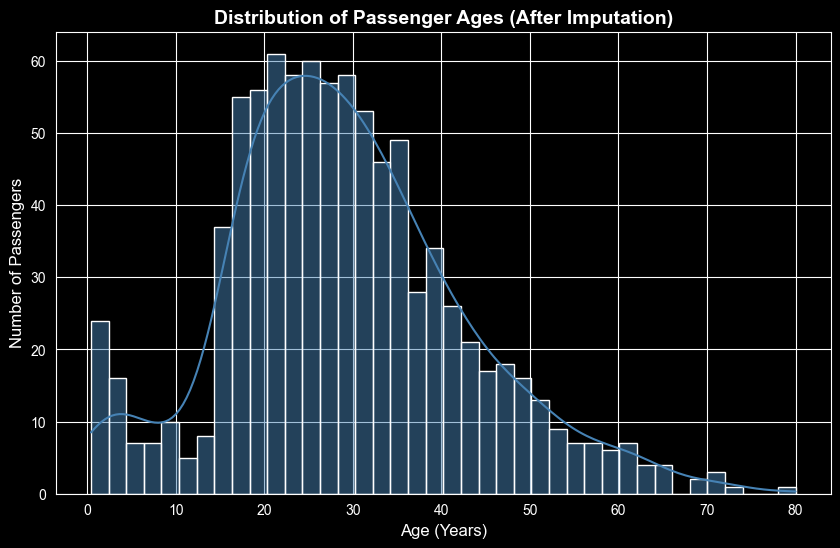

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Age'], bins=40, kde=True, color='steelblue')

plt.title('Distribution of Passenger Ages (After Imputation)', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

plt.show()

In [16]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

## Countplots and Barplots with **SEABORN**: The Embarkation Ports

Seaborn has a built-in function called countplot() specifically designed for this exact scenario.
You don't even have to calculate the totals yourself; Seaborn does the math for you behind the scenes.

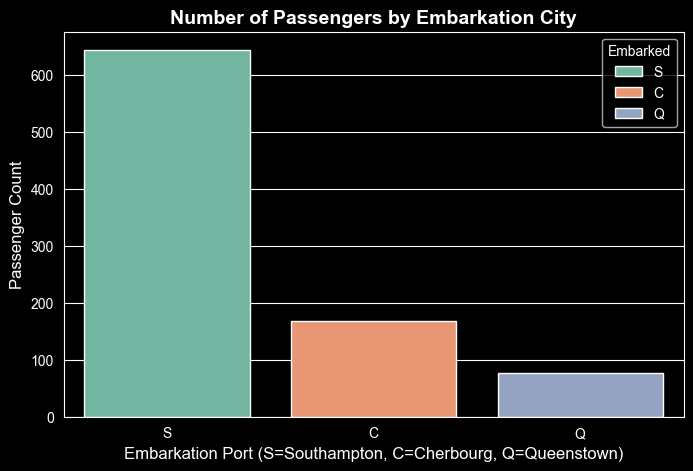

In [18]:
# C = Cherbourg, Q = Queenstown, S = Southampton
# https://seaborn.pydata.org/generated/seaborn.countplot.html#seaborn-countplot
plt.figure(figsize=(8, 5))

# Seaborn automatically counts the occurrences of each category in 'Embarked'
sns.countplot(data=df, x='Embarked', hue='Embarked', palette='Set2', legend=True)

plt.title('Number of Passengers by Embarkation City', fontsize=14, fontweight='bold')
plt.xlabel('Embarkation Port (S=Southampton, C=Cherbourg, Q=Queenstown)', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)

plt.show()

## **The Pandas + Matplotlib**

You can manually calculate the counts using pandas and plot it using matplotlib.

Histograms display the distribution of continuous numerical data using touching bars to show frequency within ranges (bins).

Bar charts compare discrete, separate categories using spaced bars.

Use histograms for trends over intervals (e.g., age groups), and bar charts for comparing distinct groups (e.g., sales by city)

In [19]:
# 1. Use pandas to calculate the exact counts
embark_counts = df['Embarked'].value_counts()
embark_counts

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

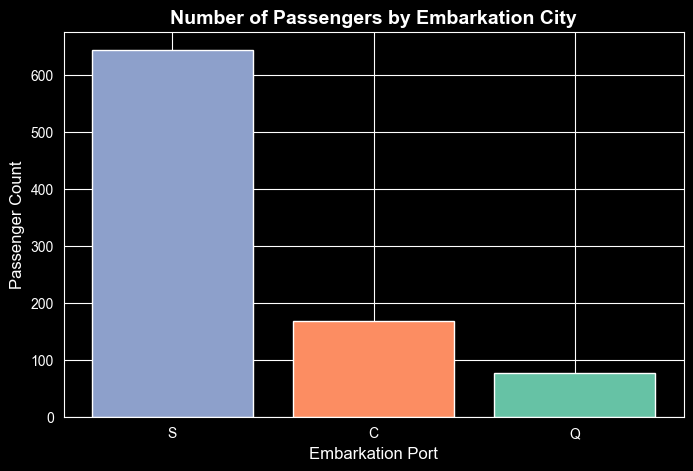

In [20]:
# By default, seaborn and matplotlib will silently ignore NaN (null) values in these plots.
plt.figure(figsize=(8, 5))

# 2. Use matplotlib to plot those counts
plt.bar(embark_counts.index, embark_counts.values, color=['#8DA0CB', '#FC8D62', '#66C2A5'])

plt.title('Number of Passengers by Embarkation City', fontsize=14, fontweight='bold')
plt.xlabel('Embarkation Port', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)

plt.show()

In [21]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [22]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## How did social class affect survival rate?

In [23]:
# 1 = 1st, 2 = 2nd, 3 = 3rd class
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

## Plotting social class percentages directly with Seaborn

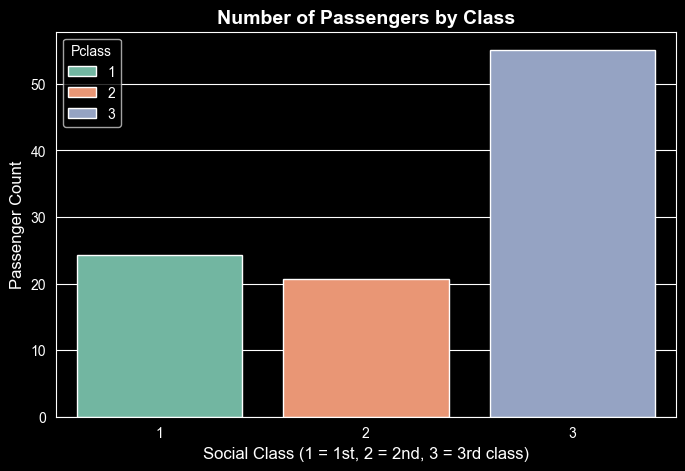

In [24]:
# https://seaborn.pydata.org/generated/seaborn.countplot.html#seaborn-countplot
plt.figure(figsize=(8, 5))

# Seaborn automatically counts the occurrences of each category AND
# stat{‘count’, ‘percent’, ‘proportion’, ‘probability’}
# Statistic to compute; when not 'count', bar heights will be normalized so that they sum to 100 (for 'percent') or 1 (otherwise) across the plot.
sns.countplot(data=df, x='Pclass', hue='Pclass', palette='Set2', stat="percent")

plt.title('Number of Passengers by Class', fontsize=14, fontweight='bold')
plt.xlabel('Social Class (1 = 1st, 2 = 2nd, 3 = 3rd class)', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)

plt.show()

## Let's now see the death toll according to social class

In [25]:
grouped = df.groupby('Pclass')['Survived'].mean()

In [26]:
print(grouped)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [27]:
# 1. Group by Pclass and find the mean of 'Survived' (Survival Rate)
# 2. Subtract from 1 to get the Death Rate, then multiply by 100 for a percentage
death_rates = (1 - df.groupby('Pclass')['Survived'].mean()) * 100
print(death_rates)

# Convert this into a clean DataFrame so Seaborn can easily read it
death_rates_df = death_rates.reset_index()
death_rates_df.rename(columns={'Survived': 'Death Percentage'}, inplace=True)
print(death_rates_df)

Pclass
1    37.037037
2    52.717391
3    75.763747
Name: Survived, dtype: float64
   Pclass  Death Percentage
0       1         37.037037
1       2         52.717391
2       3         75.763747


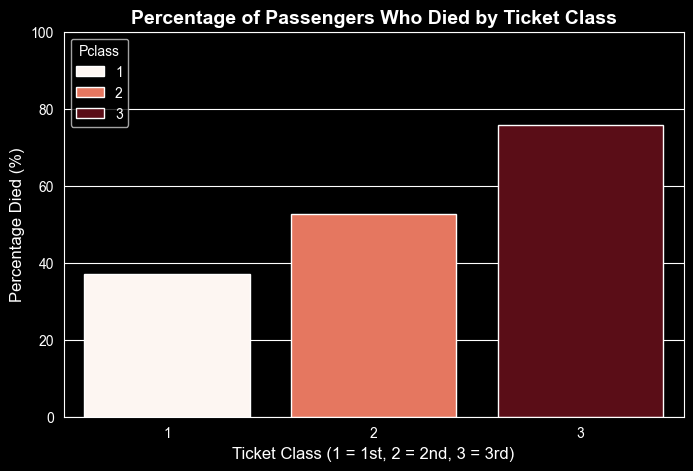

In [28]:
plt.figure(figsize=(8, 5))

# https://seaborn.pydata.org/generated/seaborn.barplot.html
sns.barplot(data=death_rates_df, x='Pclass', y='Death Percentage', hue='Pclass', palette='Reds')

plt.title('Percentage of Passengers Who Died by Ticket Class', fontsize=14, fontweight='bold')
plt.xlabel('Ticket Class (1 = 1st, 2 = 2nd, 3 = 3rd)', fontsize=12)
plt.ylabel('Percentage Died (%)', fontsize=12)

# Set the y-axis to go from 0 to 100 so the percentages are in proper context
# If you don't lock the y-axis to 100, Matplotlib will automatically zoom the axis in to end right above the highest bar (around 80%). This artificially exaggerates the differences between the bars.
plt.ylim(0, 100)

plt.show()

## Women and children first

In [22]:
grouped2 = df.groupby(['Pclass', 'Sex'])['Survived'].mean()
grouped2

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

In [29]:
# 1. Group by BOTH Pclass and Sex
death_rates_gender = (1 - df.groupby(['Pclass', 'Sex'])['Survived'].mean()) * 100

# 2. Reset the index so seaborn can read it as a standard DataFrame
death_rates_df = death_rates_gender.reset_index()

# 3. Rename the column for clarity
death_rates_df.rename(columns={'Survived': 'Death Percentage'}, inplace=True)

print(death_rates_df)

   Pclass     Sex  Death Percentage
0       1  female          3.191489
1       1    male         63.114754
2       2  female          7.894737
3       2    male         84.259259
4       3  female         50.000000
5       3    male         86.455331


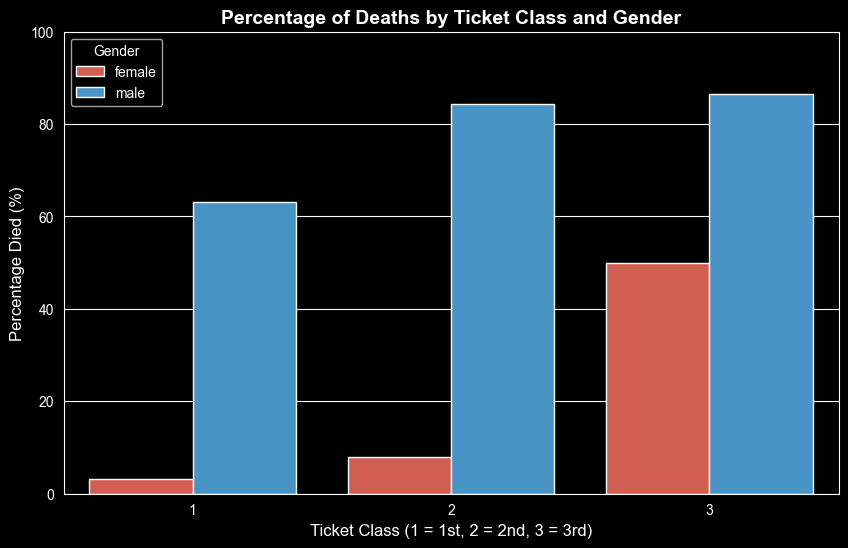

In [31]:
plt.figure(figsize=(10, 6))

# The 'hue' parameter splits the Pclass bars into Male and Female bars side-by-side
# We can use a custom dictionary in 'palette' to assign specific colors
sns.barplot(
    data=death_rates_df,
    x='Pclass',
    y='Death Percentage',
    hue='Sex',
    palette={'male': '#3498db', 'female': '#e74c3c'}
)

plt.title('Percentage of Deaths by Ticket Class and Gender', fontsize=14, fontweight='bold')
plt.xlabel('Ticket Class (1 = 1st, 2 = 2nd, 3 = 3rd)', fontsize=12)
plt.ylabel('Percentage Died (%)', fontsize=12)

# Keep the y-axis locked to 100 for accurate visual representation!
plt.ylim(0, 100)

# Move the legend outside the chart if it overlaps the bars
plt.legend(title='Gender', loc='upper left')

plt.show()

## **Violin Plot**

a Box Plot + a Kernel Density Estimate (KDE) Plot.


**1. The Core (The Summary Statistics)**
Inside the center of the violin, there is usually a miniature box plot:

**The White Dot**: This is the median (the exact middle value of the dataset).

**The Thick Black Bar:** This represents the Interquartile Range (IQR). It shows where the middle 50% of your data lives.

**The Thin Black Lines (Whiskers):** These extend to show the rest of the distribution, stopping at the outliers.

**2. The Shell (The Density)**
The colorful outer shape (the "violin") is a density curve turned on its side and mirrored to make it symmetrical.

Wide sections: A wider section means there is a high frequency of data points at that specific value.

Skinny sections: A narrow section means very few data points exist there.



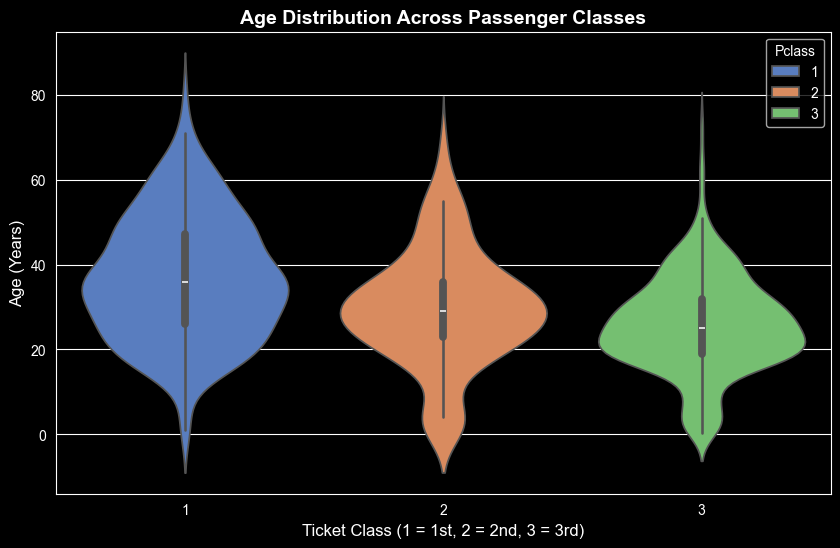

In [32]:
plt.figure(figsize=(10, 6))

# A violin plot requires a categorical x-axis (Pclass) and a numerical y-axis (Age)
sns.violinplot(data=df, x='Pclass', y='Age', hue='Pclass', palette='muted')

plt.title('Age Distribution Across Passenger Classes', fontsize=14, fontweight='bold')
plt.xlabel('Ticket Class (1 = 1st, 2 = 2nd, 3 = 3rd)', fontsize=12)
plt.ylabel('Age (Years)', fontsize=12)

plt.show()

**Kernel Density Estimate (KDE) plot**
https://www.youtube.com/watch?v=DCgPRaIDYXA

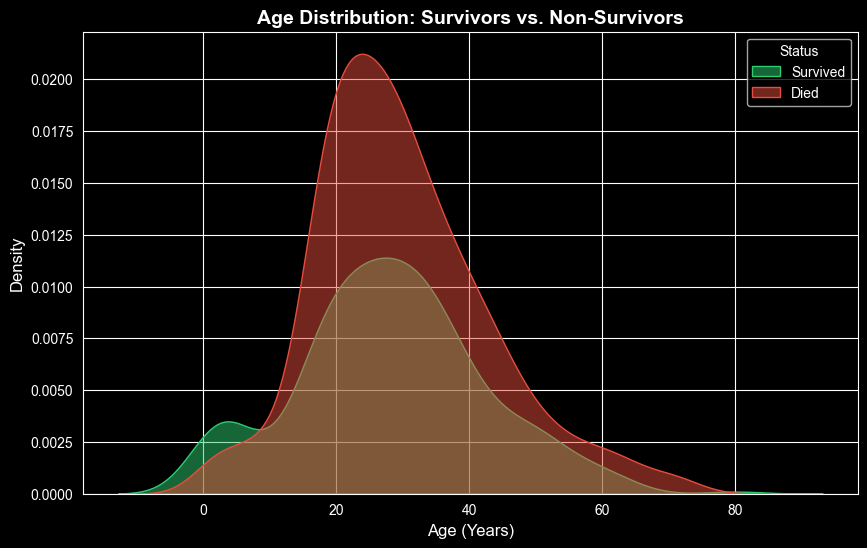

In [33]:

plt.figure(figsize=(10, 6))

# Use a KDE plot to show smooth distributions
# fill=True makes the curves semi-transparent so we can see overlaps
# palette sets distinct colors for Died (0) and Survived (1)
sns.kdeplot(
    data=df,
    x='Age',
    hue='Survived',
    fill=True,
    palette={0: '#e74c3c', 1: '#2ecc71'}, # Red for died, Green for survived
    alpha=0.5 # Controls the transparency
)

plt.title('Age Distribution: Survivors vs. Non-Survivors', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Update the legend for clarity
plt.legend(title='Status', labels=['Survived', 'Died'])

plt.show()

In [ ]:
df['Age'].unique()

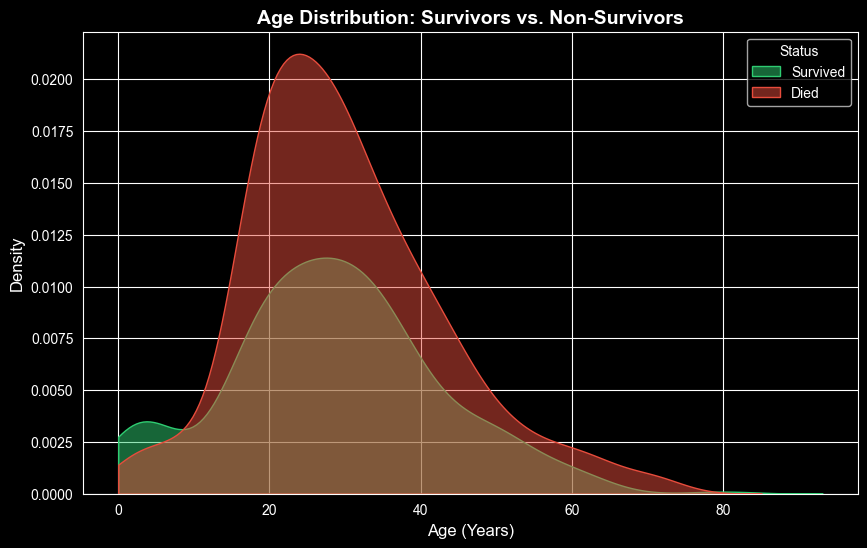

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='Age',
    hue='Survived',
    fill=True,
    palette={0: '#e74c3c', 1: '#2ecc71'},
    alpha=0.5,
    clip=(0, None) # <--- This is the magic fix! It builds a wall at zero.
)

plt.title('Age Distribution: Survivors vs. Non-Survivors', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.legend(title='Status', labels=['Survived', 'Died'])

plt.show()

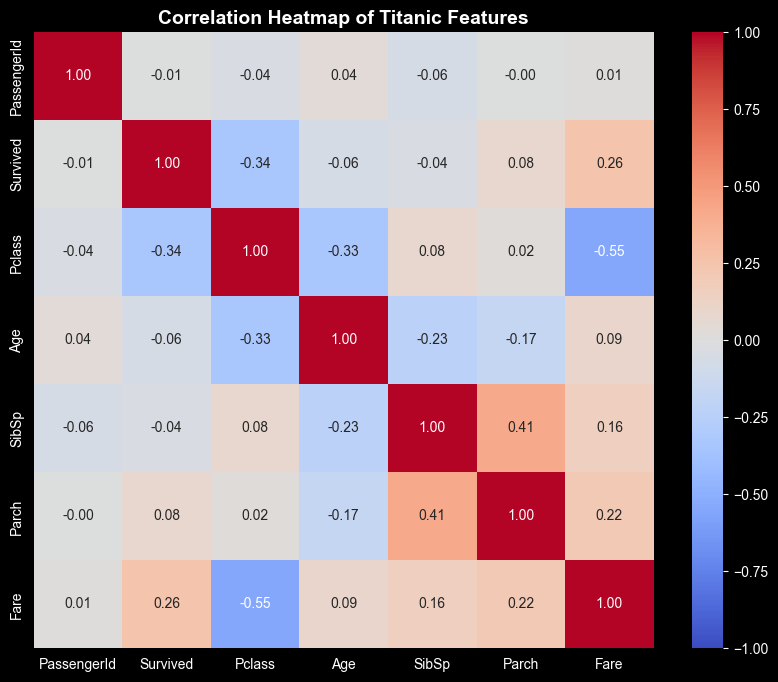

In [35]:
plt.figure(figsize=(10, 8))

# 1. Isolate only the numerical columns to avoid correlation errors
numeric_df = df.select_dtypes(include=['number'])

# 2. Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# 3. Plot the heatmap
# annot=True puts the actual numbers inside the squares
# cmap='coolwarm' makes negative correlations blue and positive correlations red
# fmt=".2f" rounds the numbers to two decimal places for readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Titanic Features', fontsize=14, fontweight='bold')

plt.show()